# Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
from kafka import  KafkaConsumer
from minio import Minio
import json
import os
from datetime import datetime
import io

kafka_config = {
    'bootstrap_servers': 'kafka1:9092',  # Update with your Kafka broker
    'serializer': lambda v: json.dumps(v).encode('utf-8'),  # Serialize data to JSON
    'deserializer': lambda v: json.loads(v.decode('utf-8'))  # Deserialize data from JSON
}



# Functions

In [2]:

def read_json_from_minio(minio_client, bucket, file_path):
    response = minio_client.get_object(bucket, file_path)
    data = json.load(response)
    return data

def json_to_df(data):
    return pd.DataFrame(data)

def list_files(minio_client, bucket, prefix):
    objects = minio_client.list_objects(bucket, prefix=prefix, recursive=True)
    return [obj.object_name for obj in objects]

def load_topic_dataframe(minio_client, bucket, topic):
    files = list_files(minio_client, bucket, f"data/{topic}/")
    
    df_list = []
    for file in files:
        data = read_json_from_minio(minio_client, bucket, file)
        df = json_to_df(data)
        df_list.append(df)

    return pd.concat(df_list, ignore_index=True)

In [3]:
# --- Configuration MinIO ---

class ConsumerManager:
    def __init__(self,config):
        self.minio_client = Minio(
            f"{os.getenv('minio_ip_address','localhost')}:3900",
            access_key=os.getenv("key_id"),
            secret_key=os.getenv("secret_key"),
            region="garage",
            secure=False
        )
        self.config = config
        self.bucket_name = os.getenv("bucket_name")
        self.consumers = {}

    def add_kafka_consumer(self, topic: str):
        print(f"Creating consumer for topic: {topic}")
        self.consumers[topic] = KafkaConsumer(
            topic,
            bootstrap_servers=self.config['bootstrap_servers'],
            value_deserializer=self.config['deserializer'],
            auto_offset_reset='earliest',
            enable_auto_commit=False,
            group_id=None,
            consumer_timeout_ms=5000,
        )
        print(f"Consumer created for {topic}")

    def upload_to_garage(self, topic: str, max_records: int = 5, timeout_ms: int = 5000):
        now = datetime.now()
        file_path = f"data/{topic}/batch_{now.strftime('%Y-%m-%d-%H%M%S')}.json"
        message_buffer = []

        records = self.consumers[topic].poll(timeout_ms=timeout_ms, max_records=max_records)
        total = sum(len(messages) for messages in records.values())
        print(f"Polled {total} message(s) from {topic}")

        for _, messages in records.items():
            for message in messages:
                message_buffer.append(message.value)
                print(message.value)

        if message_buffer:
            try:
                json_data = json.dumps(message_buffer).encode('utf-8')
                self.minio_client.put_object(
                    self.bucket_name,
                    file_path,
                    io.BytesIO(json_data),
                    length=len(json_data),
                    content_type='application/json'
                )
                print(f"[OK] {len(message_buffer)} messages sauvegardés dans : {file_path}")
            except Exception as e:
                print(f"[ERREUR] Impossible d'écrire dans MinIO : {e}")
        else:
            print(f"[INFO] Aucun message reçu pour le topic : {topic}")

# Data-reading

In [4]:
consumer_manager = ConsumerManager(kafka_config)

df_line_reports = load_topic_dataframe(
    consumer_manager.minio_client,
    consumer_manager.bucket_name,
    "line_reports"
)

In [74]:
consumer_manager = ConsumerManager(kafka_config)
consumer_manager.add_kafka_consumer("line_reports")

# Poller directement les messages depuis Kafka
records = consumer_manager.consumers["line_reports"].poll(timeout_ms=5000, max_records=1000)

# Extraire uniquement les valeurs (le JSON des messages)
raw_data = [msg.value for partition in records.values() for msg in partition]

# Supposons que ton JSON soit déjà chargé dans raw_data (liste de dicts)
rows = []
for i in raw_data:
    for entry in i:
        line = entry.get("line", {})
        line_name = line.get("name")
        line_network = line.get("network", {}).get("name")
        line_transport = ", ".join(mode.get("name") for mode in line.get("physical_modes", []))
        line_links = line.get("links", [])
        line_opening_time = pd.to_datetime(
                line.get('opening_time'), format='%H%M%S', errors='coerce'
            ),
        line_closing_time =pd.to_datetime(
                line.get('closing_time'), format='%H%M%S', errors='coerce'
            ),
        line_incidents = len([l for l in line_links if l.get("type") == "disruption"])

        pt_objects = entry.get("pt_objects", [])
        if not pt_objects:
            rows.append({
                "line": line,
                "line_name": line_name,
                "line_network":line_network,
                "transport": line_transport,
                'opening_time': line_opening_time,
                'closing_time': line_closing_time,
                "stop_name": None,
                "line_incidents": line_incidents,
                "stop_incidents": 0
            })
        else:
            for pt in pt_objects:
                stop_area = pt.get("stop_area", {})
                stop_name = stop_area.get("name")
                stop_links = stop_area.get("links", [])
                stop_incidents = len([l for l in stop_links if l.get("type") == "disruption"])
                rows.append({
                    "line" : line,
                    "line_name": line_name,
                    "line_network":line_network,
                    "transport": line_transport,
                    'opening_time': line_opening_time,
                    'closing_time': line_closing_time,
                    "stop_name": stop_name,
                    "line_incidents": line_incidents,
                    "stop_incidents": stop_incidents
                })

# Créer le DataFrame pandas
df = pd.DataFrame(rows)

Creating consumer for topic: line_reports
Consumer created for line_reports


# Structure of the DataFrame

DataFrame of shape (100, 5) where each row represents one document, and each cell contains structured JSON-like data

In [75]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1384 entries, 0 to 1383
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   line            1384 non-null   object
 1   line_name       1384 non-null   str   
 2   line_network    1384 non-null   str   
 3   transport       1384 non-null   str   
 4   opening_time    1384 non-null   object
 5   closing_time    1384 non-null   object
 6   stop_name       271 non-null    str   
 7   line_incidents  1384 non-null   int64 
 8   stop_incidents  1384 non-null   int64 
dtypes: int64(2), object(3), str(4)
memory usage: 135.4+ KB


,line,line_name,line_network,transport,opening_time,closing_time,stop_name,line_incidents,stop_incidents
0,"{'id': 'line:IDFM:C00637', 'name': '7718', 'co...",7718,Meaux et Ourcq,Bus,"(1900-01-01 04:15:00,)","(1900-01-01 00:41:00,)",Val d'Europe,0,1
1,"{'id': 'line:IDFM:C00661', 'name': '7720', 'co...",7720,Meaux et Ourcq,Bus,"(1900-01-01 04:00:00,)","(1900-01-01 00:46:00,)",Aéroport CDG 1 (Terminal 3),0,1
2,"{'id': 'line:IDFM:C01639', 'name': 'N141', 'co...",N141,Meaux et Ourcq,Bus,"(1900-01-01 00:30:00,)","(1900-01-01 06:15:00,)",Chelles - Gournay,0,2
3,"{'id': 'line:IDFM:C01639', 'name': 'N141', 'co...",N141,Meaux et Ourcq,Bus,"(1900-01-01 00:30:00,)","(1900-01-01 06:15:00,)",Vaires - Torcy,0,1
4,"{'id': 'line:IDFM:C02489', 'name': 'Soir Meaux...",Soir Meaux Nord,Meaux et Ourcq,Bus,"(1900-01-01 21:50:00,)","(1900-01-01 02:19:00,)",NaN,1,0


Here we do a JOIN ON 'line.name'between the 'line' and the 'pt_objects' dataframe in order to see the network linked to the each stop.

In [30]:
df_networks = df.groupby("line_network")["line_name"].nunique().reset_index()

df_networks = df_networks.rename(columns={
    "line_name": "nb_lines"
})

df_networks = df_networks.sort_values(by="nb_lines", ascending=False)

display(df_networks)

,line_network,nb_lines
29,Roissy Ouest,60
26,Pays Briard,55
1,Argenteuil - Boucles de Seine,49
13,Evry Centre Essonne,45
28,Roissy Est,40
7,Centre et Sud Yvelines,30
18,Haut Val d'Oise,25
24,Paris Saclay,23
4,Bord de Marne,20
6,Brie et 2 Morin,19


Let's see the kind of transport we have in thoses lines

In [38]:
df_transport = df.groupby("transport")["line_name"].nunique().reset_index()

df_transport = df_transport.rename(columns={
    "line_name": "nb_lines"
})

display(df_transport)

,transport,nb_lines
0,Bus,487
1,"Orlyval, CDG VAL",1


Let's try to find the number of stop from each lines in order to see which one is the largest.

<Axes: xlabel='line_name'>

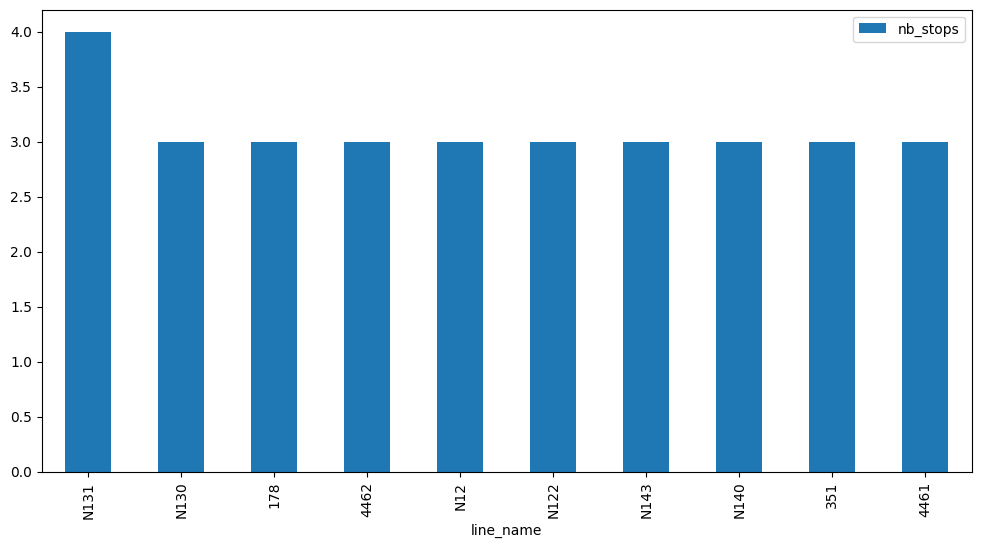

In [42]:
df_stops_per_line = df.groupby("line_name")["stop_name"].nunique().reset_index()

df_stops_per_line = df_stops_per_line.rename(columns={
    "stop_name": "nb_stops"
})

df_stops_per_line = df_stops_per_line.sort_values(by="nb_stops", ascending=False)

df_stops_per_line.head(10).plot(
    x="line_name",
    y="nb_stops",
    kind="bar",
    figsize=(12,6)
)

Using SparkSQL DataFrame

In [76]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("LineStops").getOrCreate()

spark_df = spark.createDataFrame(df)
spark_df.createOrReplaceTempView("stops")

top10_lines_sql = spark.sql("""
SELECT
    line_name,
    COUNT(DISTINCT stop_name) AS nb_stops
FROM stops
GROUP BY line_name
ORDER BY nb_stops DESC
LIMIT 10
""")

top10_lines_sql.show()


+---------+--------+
|line_name|nb_stops|
+---------+--------+
|     N140|       4|
|      351|       4|
|     N143|       4|
|      N12|       4|
|      178|       4|
|     N131|       4|
|     N130|       4|
|     N122|       3|
|     N142|       3|
|     N139|       3|
+---------+--------+

